# MBS Prediction Tasks — Multi-Model Comparison
## Three Tasks × Seven Models

| # | Task | Target | Type |
|---|---|---|---|
| 1 | CPR Regression | `cpr_next` (continuous) | Regression |
| 2 | High-Prepayment Flag | `high_cpr` (binary) | Classification |
| 3 | CPR Direction Change | `cpr_direction` (binary) | Classification |

**Models:** Ridge/Logistic · Lasso · Random Forest · XGBoost · LightGBM · Stacking Ensemble · PyTorch MLP

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.ensemble import StackingRegressor, StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
import xgboost as xgb
import lightgbm as lgb

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f8f9fa',
    'axes.grid':True,'grid.alpha':0.4,'font.size':11,
    'axes.titlesize':12,'axes.titleweight':'bold'
})
np.random.seed(42)
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
COLORS = {'Ridge':'#3B8BD4','Logistic (L2)':'#3B8BD4','Lasso':'#1D9E75','Random Forest':'#7F77DD',
          'XGBoost':'#D85A30','LightGBM':'#BA7517','Stacking':'#D4537E','PyTorch MLP':'#111827'}
print(f'Libraries loaded | PyTorch device: {DEVICE}')

Libraries loaded


## 1. Data Generation

In [2]:
def simulate_mbs(n_pools=10, start='2013-01-01', end='2024-12-01', seed=42):
    np.random.seed(seed)
    dates = pd.date_range(start, end, freq='MS')
    T = len(dates)
    t = np.arange(T)
    rate_10y   = np.clip(2.5 - 1.2*np.sin(np.pi*t/T) + 0.8*(t>96).astype(float)
                         + np.random.normal(0, 0.12, T), 0.4, 5.2)
    refi_index = np.clip(255 - 42*rate_10y + np.random.normal(0, 18, T), 45, 420)
    vix        = np.clip(18 + 8*np.sin(2*np.pi*t/36) + np.random.exponential(4, T), 10, 70)
    hpa        = np.clip(0.05 + 0.03*np.sin(np.pi*t/T) + np.random.normal(0, 0.015, T), -0.10, 0.18)

    records = []
    cfgs = [{'pool_id': f'POOL-{i+1:03d}',
              'wac': np.random.uniform(2.8, 6.8),
              'wam': np.random.randint(200, 360),
              'ltv': np.random.uniform(60, 95),
              'fico': np.random.randint(640, 800)}
             for i in range(n_pools)]

    for cfg in cfgs:
        wac, wam, ltv, fico = cfg['wac'], cfg['wam'], cfg['ltv'], cfg['fico']
        factor   = 1.0
        prev_cpr = None
        for i, dt in enumerate(dates):
            r   = rate_10y[i]
            inc = wac - r
            cpr = np.clip(
                6.0 + 20.0/(1+np.exp(-2.5*(inc-0.5)))
                - 4*(1-factor)
                + 2.5*np.sin(2*np.pi*(dt.month-3)/12)
                - 0.1*max(0, ltv-80)
                + 0.02*(fico-720)
                + 5*hpa[i]
                + np.random.normal(0, 1.5),
                0.5, 65.0)
            spread = np.clip(85 - 16*inc + 0.3*ltv + np.random.normal(0,8), 10, 260)
            records.append({'date':dt,'pool_id':cfg['pool_id'],
                            'cpr':round(cpr,2),'wac':round(wac,3),
                            'wam':max(1,wam-i),'ltv':round(ltv,1),'fico':fico,
                            'refi_index':round(refi_index[i],1),
                            'rate_10y':round(r,3),'spread_to_treasury':round(spread,1),
                            'factor':round(factor,4),'vix':round(vix[i],1),'hpa':round(hpa[i],4),
                            'prev_cpr':round(prev_cpr,2) if prev_cpr else np.nan})
            smm    = 1-(1-cpr/100)**(1/12)
            factor = max(0.01, factor*(1-smm)*(1-1/max(1,wam-i)))
            prev_cpr = cpr

    return pd.DataFrame(records).sort_values(['pool_id','date']).reset_index(drop=True)

df_raw = simulate_mbs(n_pools=10)
print(f'Shape: {df_raw.shape}  |  Pools: {df_raw.pool_id.nunique()}  |  '
      f'{df_raw.date.min().date()} to {df_raw.date.max().date()}')

Shape: (1440, 14)  |  Pools: 10  |  2013-01-01 to 2024-12-01


## 2. Feature Engineering

In [3]:
def engineer_features(df):
    d = df.copy()
    # Refi signal
    d['refi_incentive']    = d['wac'] - d['rate_10y']
    d['refi_incentive_sq'] = d['refi_incentive']**2
    d['refi_incentive_cb'] = d['refi_incentive']**3
    d['in_the_money']      = (d['refi_incentive'] > 0.5).astype(int)
    # Pool
    d['burnout']           = 1 - d['factor']
    d['ltv_kink']          = np.clip(d['ltv'] - 80, 0, None)
    d['fico_norm']         = (d['fico'] - 720) / 50
    # Seasonality
    d['month_sin']         = np.sin(2*np.pi*d['date'].dt.month/12)
    d['month_cos']         = np.cos(2*np.pi*d['date'].dt.month/12)
    # Market
    d['refi_x_factor']     = d['refi_incentive'] * (1 - d['factor'])
    d['spread_norm']       = d['spread_to_treasury'] / 100
    d['vix_norm']          = d['vix'] / 30
    # Lag features per pool
    for pid, grp in d.groupby('pool_id'):
        idx = grp.index
        d.loc[idx,'cpr_lag1']  = grp['cpr'].shift(1)
        d.loc[idx,'cpr_lag3']  = grp['cpr'].shift(3)
        d.loc[idx,'cpr_ma3']   = grp['cpr'].shift(1).rolling(3).mean()
        d.loc[idx,'rate_chg1'] = grp['rate_10y'].diff(1)
        d.loc[idx,'rate_chg3'] = grp['rate_10y'].diff(3)
    # Targets
    d['cpr_next']      = d.groupby('pool_id')['cpr'].shift(-1)
    d['high_cpr']      = (d['cpr_next'] > d['cpr_next'].quantile(0.70)).astype(int)
    d['cpr_direction'] = (d.groupby('pool_id')['cpr'].shift(-1) > d['cpr']).astype(int)
    return d.dropna().reset_index(drop=True)

df = engineer_features(df_raw)

FEATURES = [
    'refi_incentive','refi_incentive_sq','refi_incentive_cb','in_the_money',
    'burnout','ltv_kink','fico_norm','wam',
    'month_sin','month_cos',
    'refi_index','refi_x_factor','spread_norm','vix_norm',
    'cpr_lag1','cpr_lag3','cpr_ma3','rate_chg1','rate_chg3'
]

CUTOFF = '2023-01-01'
train  = df[df['date'] <  CUTOFF].copy()
test   = df[df['date'] >= CUTOFF].copy()
X_train, X_test = train[FEATURES], test[FEATURES]

print(f'Features: {len(FEATURES)}')
print(f'Train: {len(train):,} rows  |  Test: {len(test):,} rows')
print(f'CPR 70th pct (high_cpr threshold): {df.cpr_next.quantile(0.70):.1f}%')

Features: 19
Train: 1,170 rows  |  Test: 230 rows
CPR 70th pct (high_cpr threshold): 23.9%


## PyTorch Deep Learning Model Design

The three tasks use the same tabular neural network backbone: a standardized-feature MLP with two hidden layers, batch normalization, ReLU activations, and dropout. For Task 1 it is trained as a regressor with MSE loss on a standardized CPR target; for Tasks 2 and 3 it is trained as a binary classifier with weighted BCE loss to handle class imbalance.

In [ ]:
class TabularMLP(nn.Module):
    def __init__(self, input_dim, hidden=(64, 32), dropout=0.15, output_dim=1):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for width in hidden:
            layers.extend([
                nn.Linear(prev_dim, width),
                nn.BatchNorm1d(width),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = width
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def _make_tabular_loaders(X_train, y_train, X_test, y_test, batch_size=64):
    scaler = StandardScaler()
    Xtr = scaler.fit_transform(X_train).astype('float32')
    Xte = scaler.transform(X_test).astype('float32')
    ytr = np.asarray(y_train, dtype='float32')
    yte = np.asarray(y_test, dtype='float32')

    train_ds = TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr))
    test_x = torch.from_numpy(Xte).to(DEVICE)
    return DataLoader(train_ds, batch_size=batch_size, shuffle=True), test_x, yte


def train_torch_regressor(X_train, y_train, X_test, y_test, epochs=350, lr=1e-3, weight_decay=1e-4):
    loader, test_x, yte = _make_tabular_loaders(X_train, y_train, X_test, y_test)
    y_mean, y_std = float(np.mean(y_train)), float(np.std(y_train))
    y_std = y_std if y_std > 0 else 1.0

    model = TabularMLP(input_dim=X_train.shape[1], hidden=(64, 32), dropout=0.10).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = ((yb.to(DEVICE) - y_mean) / y_std)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(test_x).cpu().numpy() * y_std + y_mean
    return model, pred


def train_torch_classifier(X_train, y_train, X_test, y_test, epochs=300, lr=1e-3, weight_decay=1e-4):
    loader, test_x, yte = _make_tabular_loaders(X_train, y_train, X_test, y_test)
    positives = max(float(np.sum(y_train)), 1.0)
    negatives = max(float(len(y_train) - np.sum(y_train)), 1.0)
    pos_weight = torch.tensor([negatives / positives], dtype=torch.float32, device=DEVICE)

    model = TabularMLP(input_dim=X_train.shape[1], hidden=(64, 32), dropout=0.20).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        logits = model(test_x)
        prob = torch.sigmoid(logits).cpu().numpy()
    pred = (prob >= 0.5).astype(int)
    return model, prob, pred

print('PyTorch tabular MLP helpers ready')

## Task 1 — CPR Regression

In [4]:
y_train_reg = train['cpr_next']
y_test_reg  = test['cpr_next']

reg_models = {
    'Ridge': Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=10.0))]),
    'Lasso': Pipeline([('sc', StandardScaler()), ('m', Lasso(alpha=0.1, max_iter=5000))]),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=8,
                                            min_samples_leaf=5, n_jobs=-1, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5,
                                  subsample=0.8, colsample_bytree=0.8,
                                  reg_alpha=0.1, random_state=42, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                                    num_leaves=31, subsample=0.8,
                                    random_state=42, verbose=-1),
    'Stacking': StackingRegressor(
        estimators=[
            ('ridge', Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=10.0))])),
            ('xgb',   xgb.XGBRegressor(n_estimators=200, learning_rate=0.05,
                                         max_depth=4, random_state=42, verbosity=0)),
            ('lgb',   lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                          max_depth=5, random_state=42, verbose=-1)),
        ],
        final_estimator=Ridge(alpha=5.0),
        cv=5
    )
}

reg_results = {}; reg_preds = {}
for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)
    pred = model.predict(X_test)
    reg_preds[name] = pred
    reg_results[name] = {
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, pred)),
        'MAE':  mean_absolute_error(y_test_reg, pred),
        'R2':   r2_score(y_test_reg, pred)
    }
    r = reg_results[name]
    print(f'{name:<16}  RMSE={r["RMSE"]:.3f}  MAE={r["MAE"]:.3f}  R2={r["R2"]:.3f}')

torch_name = 'PyTorch MLP'
_, torch_reg_pred = train_torch_regressor(X_train, y_train_reg, X_test, y_test_reg)
reg_preds[torch_name] = torch_reg_pred
reg_results[torch_name] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, torch_reg_pred)),
    'MAE':  mean_absolute_error(y_test_reg, torch_reg_pred),
    'R2':   r2_score(y_test_reg, torch_reg_pred)
}
r = reg_results[torch_name]
print(f'{torch_name:<16}  RMSE={r["RMSE"]:.3f}  MAE={r["MAE"]:.3f}  R2={r["R2"]:.3f}')

naive_rmse = np.sqrt(mean_squared_error(y_test_reg, test['cpr'].values))
print(f'\nNaive baseline (CPR_t as forecast): RMSE={naive_rmse:.3f}')

Ridge             RMSE=2.303  MAE=1.746  R2=0.769
Lasso             RMSE=2.595  MAE=1.937  R2=0.707


Random Forest     RMSE=2.744  MAE=1.995  R2=0.673


XGBoost           RMSE=2.504  MAE=1.863  R2=0.727


LightGBM          RMSE=2.550  MAE=1.875  R2=0.717


Stacking          RMSE=2.237  MAE=1.714  R2=0.782

Naive baseline (CPR_t as forecast): RMSE=2.592


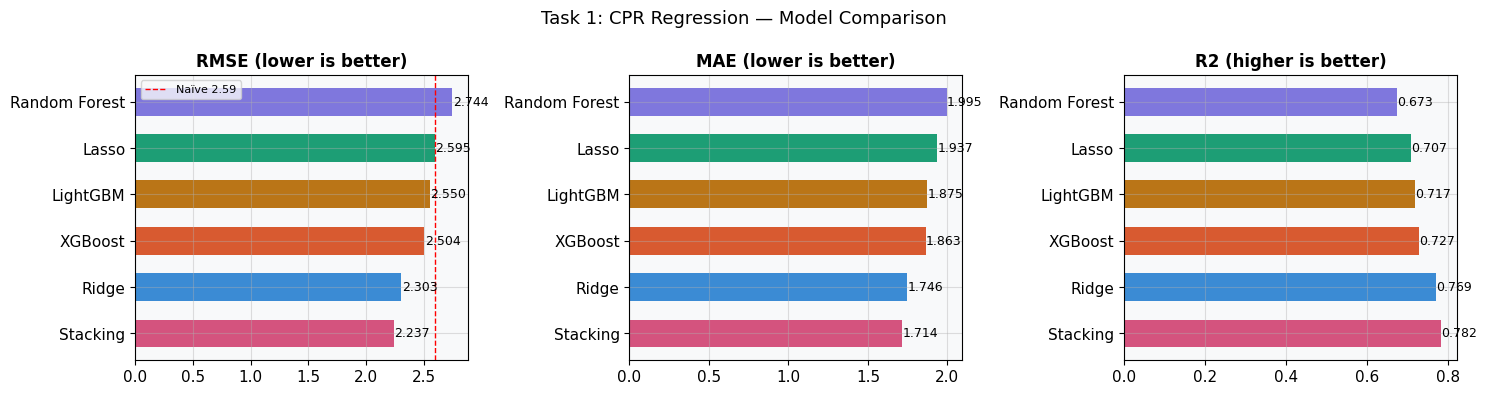

In [5]:
rr = pd.DataFrame(reg_results).T.reset_index().rename(columns={'index':'Model'})
rr = rr.sort_values('RMSE')
bar_c = [COLORS[m] for m in rr['Model']]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric, better in zip(axes, ['RMSE','MAE','R2'], ['lower','lower','higher']):
    vals = rr[metric].astype(float)
    ax.barh(rr['Model'], vals, color=bar_c, height=0.6)
    for i, (m, v) in enumerate(zip(rr['Model'], vals)):
        ax.text(v + np.ptp(vals)*0.01, i, f'{v:.3f}', va='center', fontsize=9)
    ax.set_title(f'{metric} ({better} is better)')
    if metric == 'RMSE':
        ax.axvline(naive_rmse, color='red', linestyle='--', lw=1, label=f'Naïve {naive_rmse:.2f}')
        ax.legend(fontsize=8)

plt.suptitle('Task 1: CPR Regression — Model Comparison', fontsize=13)
plt.tight_layout()
plt.show()

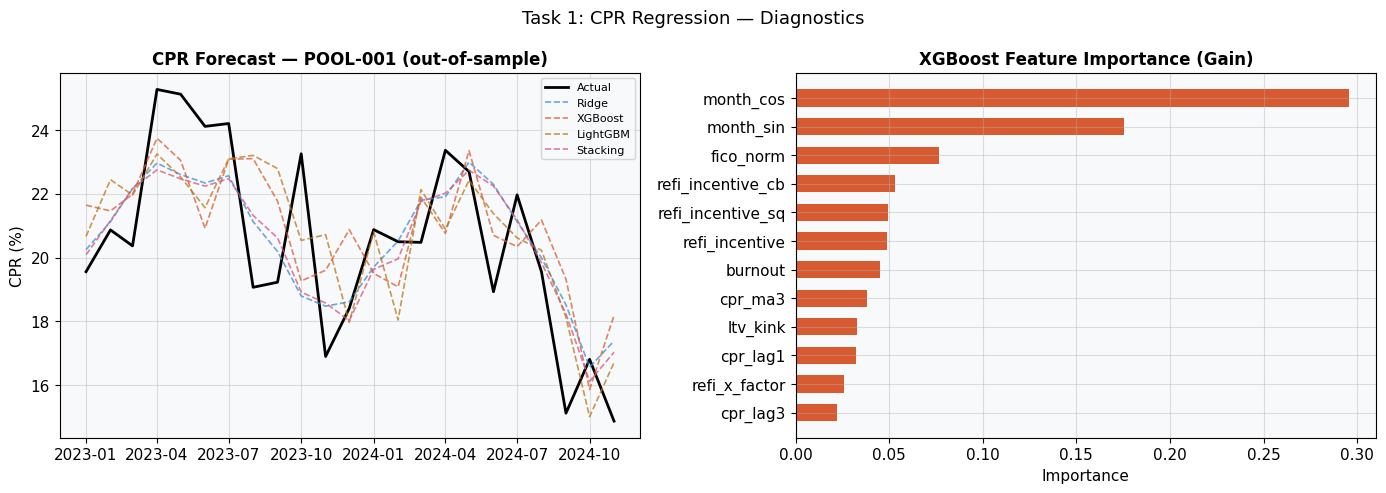

In [6]:
# Actual vs predicted for one pool, + feature importance
best_reg = rr.iloc[0]['Model']
pool_id  = 'POOL-001'
pool_test = test[test['pool_id'] == pool_id].copy()
test_idx_map = {idx: i for i, idx in enumerate(test.index)}
pool_positions = [test_idx_map[i] for i in pool_test.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(pool_test['date'], pool_test['cpr_next'], 'k-', lw=2, label='Actual')
for name in ['Ridge','XGBoost','LightGBM','Stacking']:
    ax.plot(pool_test['date'], reg_preds[name][pool_positions],
            '--', alpha=0.75, lw=1.2, label=name, color=COLORS[name])
ax.set_title(f'CPR Forecast — {pool_id} (out-of-sample)')
ax.set_ylabel('CPR (%)')
ax.legend(fontsize=8)

xgb_model = reg_models['XGBoost']
fi = pd.DataFrame({'feature': FEATURES, 'importance': xgb_model.feature_importances_})\
       .sort_values('importance', ascending=False).head(12)
ax = axes[1]
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color='#D85A30', height=0.6)
ax.set_title('XGBoost Feature Importance (Gain)')
ax.set_xlabel('Importance')

plt.suptitle('Task 1: CPR Regression — Diagnostics', fontsize=13)
plt.tight_layout()
plt.show()

## Task 2 — High-CPR Classification

In [7]:
y_train_clf = train['high_cpr']
y_test_clf  = test['high_cpr']
print(f'Positive rate — train: {y_train_clf.mean():.1%}  test: {y_test_clf.mean():.1%}')

clf_models = {
    'Logistic (L2)': Pipeline([('sc', StandardScaler()),
                                ('m', LogisticRegression(C=0.5, max_iter=1000, random_state=42))]),
    'Lasso':         Pipeline([('sc', StandardScaler()),
                                ('m', LogisticRegression(C=0.5, penalty='l1', solver='saga',
                                                         max_iter=2000, random_state=42))]),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=5,
                                             class_weight='balanced', n_jobs=-1, random_state=42),
    'XGBoost':       xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=5,
                                        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=2,
                                        random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM':      lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                                          class_weight='balanced', random_state=42, verbose=-1),
    'Stacking':      StackingClassifier(
        estimators=[
            ('lr',  Pipeline([('sc', StandardScaler()),
                              ('m',  LogisticRegression(C=0.5, max_iter=1000))])),
            ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                        random_state=42, verbosity=0, eval_metric='logloss')),
            ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                         max_depth=5, random_state=42, verbose=-1)),
        ],
        final_estimator=LogisticRegression(C=1.0, max_iter=500),
        cv=5
    )
}

clf_results = {}; clf_proba = {}; clf_pred = {}
for name, model in clf_models.items():
    model.fit(X_train, y_train_clf)
    prob = model.predict_proba(X_test)[:,1]
    pred = model.predict(X_test)
    clf_proba[name] = prob; clf_pred[name] = pred
    clf_results[name] = {
        'Accuracy': accuracy_score(y_test_clf, pred),
        'AUC':      roc_auc_score(y_test_clf, prob),
        'F1':       f1_score(y_test_clf, pred)
    }
    r = clf_results[name]
    print(f'{name:<18}  Acc={r["Accuracy"]:.3f}  AUC={r["AUC"]:.3f}  F1={r["F1"]:.3f}')

torch_name = 'PyTorch MLP'
_, torch_prob, torch_pred = train_torch_classifier(X_train, y_train_clf, X_test, y_test_clf)
clf_proba[torch_name] = torch_prob; clf_pred[torch_name] = torch_pred
clf_results[torch_name] = {
    'Accuracy': accuracy_score(y_test_clf, torch_pred),
    'AUC':      roc_auc_score(y_test_clf, torch_prob),
    'F1':       f1_score(y_test_clf, torch_pred)
}
r = clf_results[torch_name]
print(f'{torch_name:<18}  Acc={r["Accuracy"]:.3f}  AUC={r["AUC"]:.3f}  F1={r["F1"]:.3f}')

Positive rate — train: 32.1%  test: 13.9%
Logistic (L2)       Acc=0.861  AUC=0.889  F1=0.238
Lasso               Acc=0.865  AUC=0.886  F1=0.279


Random Forest       Acc=0.857  AUC=0.894  F1=0.353


XGBoost             Acc=0.874  AUC=0.878  F1=0.408


LightGBM            Acc=0.874  AUC=0.882  F1=0.356


Stacking            Acc=0.874  AUC=0.877  F1=0.293


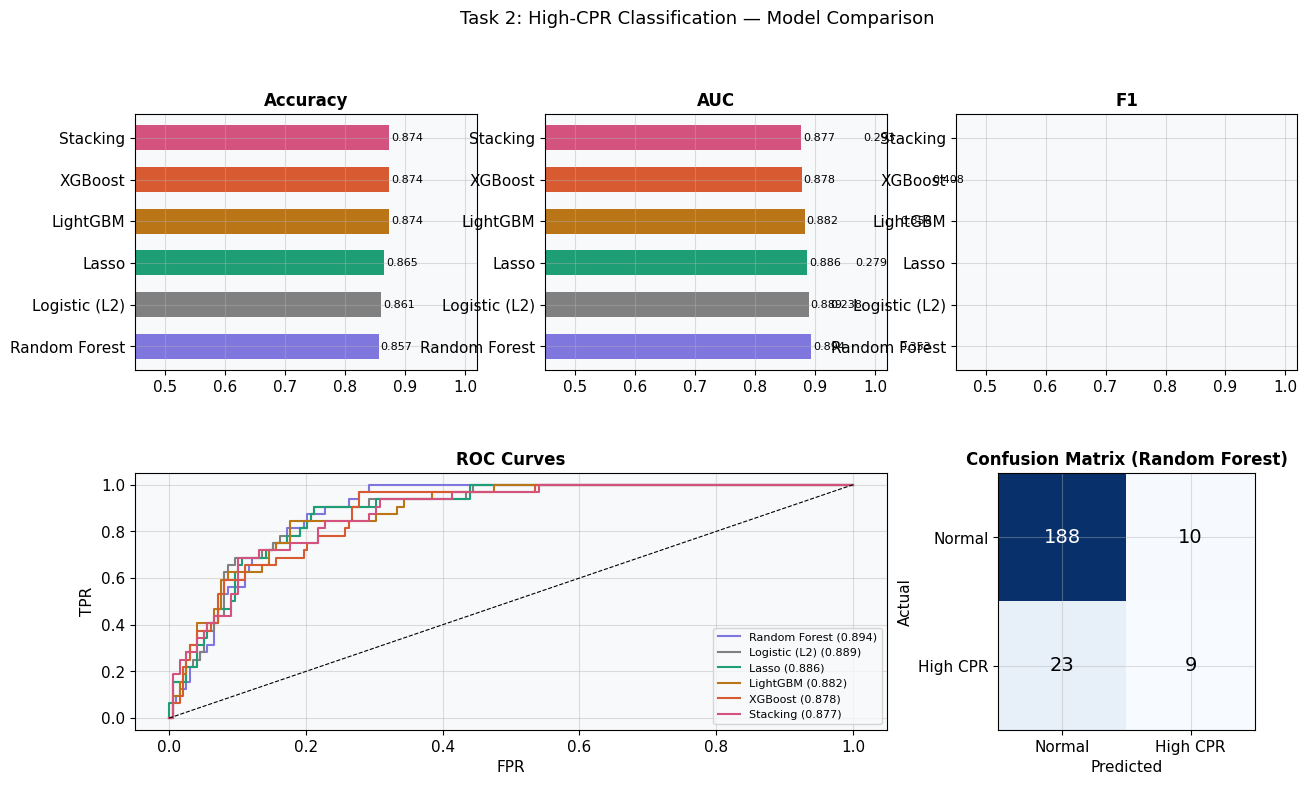


Best: Random Forest  AUC=0.894
              precision    recall  f1-score   support

      Normal       0.89      0.95      0.92       198
    High CPR       0.47      0.28      0.35        32

    accuracy                           0.86       230
   macro avg       0.68      0.62      0.64       230
weighted avg       0.83      0.86      0.84       230



In [8]:
cr = pd.DataFrame(clf_results).T.reset_index().rename(columns={'index':'Model'})
cr = cr.sort_values('AUC', ascending=False)
best_clf = cr.iloc[0]['Model']

fig = plt.figure(figsize=(15, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4)

for j, metric in enumerate(['Accuracy','AUC','F1']):
    ax = fig.add_subplot(gs[0, j])
    vals = cr[metric].astype(float)
    ax.barh(cr['Model'], vals, color=[COLORS.get(m,'gray') for m in cr['Model']], height=0.6)
    for i, (m, v) in enumerate(zip(cr['Model'], vals)):
        ax.text(v+0.003, i, f'{v:.3f}', va='center', fontsize=8)
    ax.set_xlim(0.45, 1.02); ax.set_title(metric)

ax_roc = fig.add_subplot(gs[1, 0:2])
for name in cr['Model']:
    fpr, tpr, _ = roc_curve(y_test_clf, clf_proba[name])
    ax_roc.plot(fpr, tpr, label=f'{name} ({clf_results[name]["AUC"]:.3f})',
                color=COLORS.get(name,'gray'), lw=1.5)
ax_roc.plot([0,1],[0,1],'k--', lw=0.8)
ax_roc.set_xlabel('FPR'); ax_roc.set_ylabel('TPR'); ax_roc.set_title('ROC Curves')
ax_roc.legend(fontsize=8)

ax_cm = fig.add_subplot(gs[1, 2])
cm = confusion_matrix(y_test_clf, clf_pred[best_clf])
ax_cm.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax_cm.text(j, i, cm[i,j], ha='center', va='center', fontsize=14,
                   color='white' if cm[i,j] > cm.max()*0.5 else 'black')
ax_cm.set_xticks([0,1]); ax_cm.set_yticks([0,1])
ax_cm.set_xticklabels(['Normal','High CPR'])
ax_cm.set_yticklabels(['Normal','High CPR'])
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('Actual')
ax_cm.set_title(f'Confusion Matrix ({best_clf})')

plt.suptitle('Task 2: High-CPR Classification — Model Comparison', fontsize=13, y=1.01)
plt.show()
print(f'\nBest: {best_clf}  AUC={cr.iloc[0]["AUC"]:.3f}')
print(classification_report(y_test_clf, clf_pred[best_clf], target_names=['Normal','High CPR']))

## Task 3 — CPR Direction Classification

In [9]:
y_train_dir = train['cpr_direction']
y_test_dir  = test['cpr_direction']
print(f'Rising CPR rate — train: {y_train_dir.mean():.1%}  test: {y_test_dir.mean():.1%}')
print(f'Naive baseline (predict majority): {max(y_test_dir.mean(), 1-y_test_dir.mean()):.3f}')

dir_models = {
    'Logistic (L2)': Pipeline([('sc', StandardScaler()),
                                ('m', LogisticRegression(C=0.3, max_iter=1000, random_state=42))]),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=6,
                                             min_samples_leaf=8, n_jobs=-1, random_state=42),
    'XGBoost':       xgb.XGBClassifier(n_estimators=400, learning_rate=0.03, max_depth=4,
                                        subsample=0.7, colsample_bytree=0.7,
                                        reg_alpha=0.5, reg_lambda=2.0,
                                        random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM':      lgb.LGBMClassifier(n_estimators=400, learning_rate=0.03, max_depth=5,
                                          num_leaves=20, min_child_samples=20,
                                          reg_alpha=0.5, random_state=42, verbose=-1),
    'Stacking':      StackingClassifier(
        estimators=[
            ('lr',  Pipeline([('sc', StandardScaler()),
                              ('m',  LogisticRegression(C=0.3, max_iter=1000))])),
            ('xgb', xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                        random_state=42, verbosity=0, eval_metric='logloss')),
            ('lgb', lgb.LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                         max_depth=4, random_state=42, verbose=-1)),
        ],
        final_estimator=LogisticRegression(C=0.5, max_iter=500),
        cv=5
    )
}

dir_results = {}; dir_proba = {}; dir_pred = {}
for name, model in dir_models.items():
    model.fit(X_train, y_train_dir)
    prob = model.predict_proba(X_test)[:,1]
    pred = model.predict(X_test)
    dir_proba[name] = prob; dir_pred[name] = pred
    dir_results[name] = {
        'Accuracy': accuracy_score(y_test_dir, pred),
        'AUC':      roc_auc_score(y_test_dir, prob),
        'F1':       f1_score(y_test_dir, pred)
    }
    r = dir_results[name]
    print(f'{name:<18}  Acc={r["Accuracy"]:.3f}  AUC={r["AUC"]:.3f}  F1={r["F1"]:.3f}')

torch_name = 'PyTorch MLP'
_, torch_prob, torch_pred = train_torch_classifier(X_train, y_train_dir, X_test, y_test_dir)
dir_proba[torch_name] = torch_prob; dir_pred[torch_name] = torch_pred
dir_results[torch_name] = {
    'Accuracy': accuracy_score(y_test_dir, torch_pred),
    'AUC':      roc_auc_score(y_test_dir, torch_prob),
    'F1':       f1_score(y_test_dir, torch_pred)
}
r = dir_results[torch_name]
print(f'{torch_name:<18}  Acc={r["Accuracy"]:.3f}  AUC={r["AUC"]:.3f}  F1={r["F1"]:.3f}')

Rising CPR rate — train: 47.2%  test: 49.1%
Naive baseline (predict majority): 0.509
Logistic (L2)       Acc=0.617  AUC=0.636  F1=0.569


Random Forest       Acc=0.639  AUC=0.647  F1=0.607


XGBoost             Acc=0.591  AUC=0.616  F1=0.561


LightGBM            Acc=0.596  AUC=0.625  F1=0.555


Stacking            Acc=0.622  AUC=0.635  F1=0.558


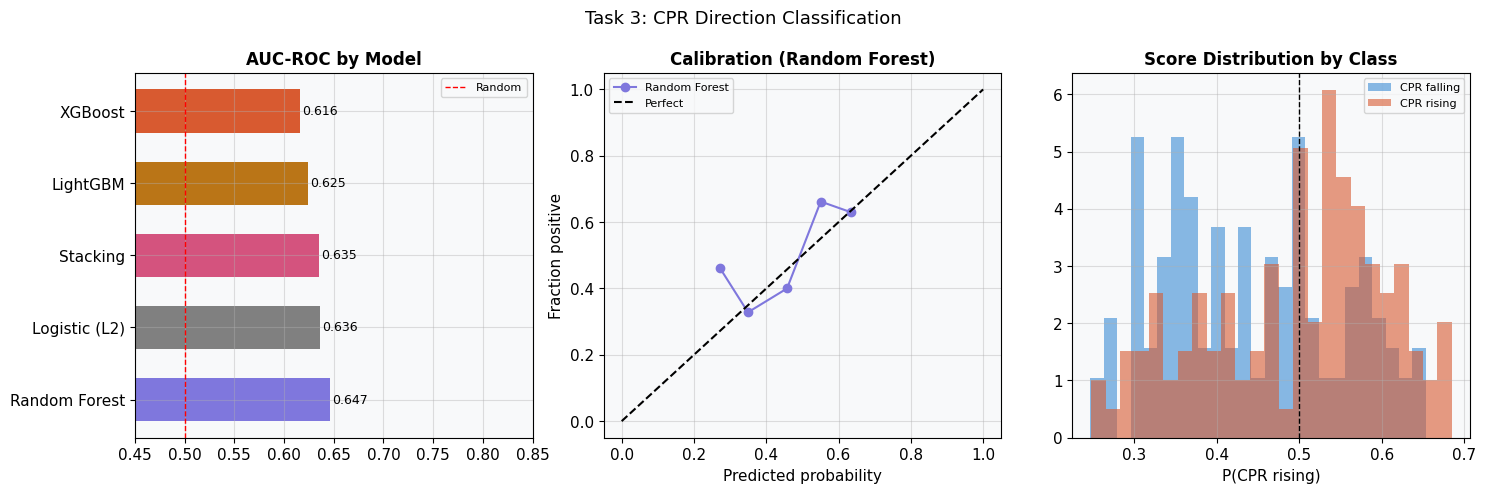

In [10]:
dr = pd.DataFrame(dir_results).T.reset_index().rename(columns={'index':'Model'})
dr = dr.sort_values('AUC', ascending=False)
best_dir = dr.iloc[0]['Model']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# AUC bar
ax = axes[0]
aucs = dr['AUC'].astype(float)
ax.barh(dr['Model'], aucs, color=[COLORS.get(m,'gray') for m in dr['Model']], height=0.6)
ax.axvline(0.5, color='red', linestyle='--', lw=1, label='Random')
for i, (m, v) in enumerate(zip(dr['Model'], aucs)):
    ax.text(v+0.002, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlim(0.45, 0.85); ax.set_title('AUC-ROC by Model'); ax.legend(fontsize=8)

# Calibration
ax = axes[1]
pt, pp = calibration_curve(y_test_dir, dir_proba[best_dir], n_bins=10)
ax.plot(pp, pt, 'o-', color=COLORS.get(best_dir,'gray'), label=best_dir)
ax.plot([0,1],[0,1],'k--', label='Perfect')
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Fraction positive')
ax.set_title(f'Calibration ({best_dir})'); ax.legend(fontsize=8)

# Score distribution
ax = axes[2]
ax.hist(dir_proba[best_dir][y_test_dir==0], bins=25, alpha=0.6, density=True,
        label='CPR falling', color='#3B8BD4')
ax.hist(dir_proba[best_dir][y_test_dir==1], bins=25, alpha=0.6, density=True,
        label='CPR rising', color='#D85A30')
ax.axvline(0.5, color='black', linestyle='--', lw=1)
ax.set_xlabel('P(CPR rising)'); ax.set_title('Score Distribution by Class')
ax.legend(fontsize=8)

plt.suptitle('Task 3: CPR Direction Classification', fontsize=13)
plt.tight_layout()
plt.show()

## Master Summary — All Tasks × All Models

               T1_RMSE  T1_MAE  T1_R2  T2_Accuracy  T2_AUC  T2_F1  T3_Accuracy  T3_AUC  T3_F1
Model                                                                                        
Ridge            2.303   1.746  0.769          NaN     NaN    NaN          NaN     NaN    NaN
Lasso            2.595   1.937  0.707        0.865   0.886  0.279          NaN     NaN    NaN
Random Forest    2.744   1.995  0.673        0.857   0.894  0.353        0.639   0.647  0.607
XGBoost          2.504   1.863  0.727        0.874   0.878  0.408        0.591   0.616  0.561
LightGBM         2.550   1.875  0.717        0.874   0.882  0.356        0.596   0.625  0.555
Stacking         2.237   1.714  0.782        0.874   0.877  0.293        0.622   0.635  0.558


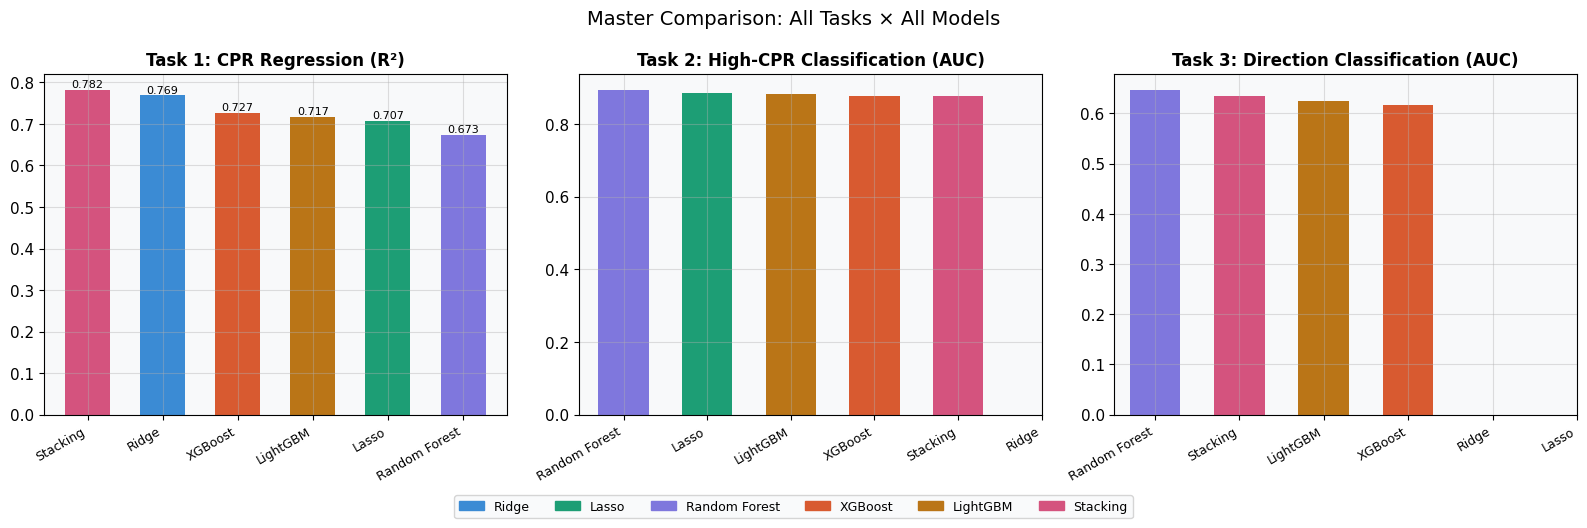


Task 1 winner: Stacking  R2=0.782
Task 2 winner: Random Forest  AUC=0.894
Task 3 winner: Random Forest  AUC=0.647


In [11]:
all_models = list(reg_results.keys())
summary_rows = []
for name in all_models:
    row = {'Model': name}
    row.update({f'T1_{k}': v for k,v in reg_results.get(name,{}).items()})
    row.update({f'T2_{k}': v for k,v in clf_results.get(name,{}).items()})
    row.update({f'T3_{k}': v for k,v in dir_results.get(name,{}).items()})
    summary_rows.append(row)

summary = pd.DataFrame(summary_rows).set_index('Model').round(3)
print(summary.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_show = ['T1_R2','T2_AUC','T3_AUC']
titles_show  = ['Task 1: CPR Regression (R²)',
                'Task 2: High-CPR Classification (AUC)',
                'Task 3: Direction Classification (AUC)']

for ax, metric, title in zip(axes, metrics_show, titles_show):
    col = summary[metric].sort_values(ascending=False)
    vals = col.values.astype(float)
    ax.bar(range(len(col)), vals, color=[COLORS.get(m,'gray') for m in col.index], width=0.6)
    for i, v in enumerate(vals):
        ax.text(i, v + np.ptp(vals)*0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(range(len(col)))
    ax.set_xticklabels(col.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(title)

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color=v, label=k) for k,v in COLORS.items()]
fig.legend(handles=patches, loc='lower center', ncol=6, fontsize=9, bbox_to_anchor=(0.5,-0.05))
plt.suptitle('Master Comparison: All Tasks × All Models', fontsize=14)
plt.tight_layout()
plt.savefig('/home/claude/master_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

best_t1 = summary['T1_R2'].idxmax()
best_t2 = summary['T2_AUC'].idxmax()
best_t3 = summary['T3_AUC'].idxmax()
print(f'\nTask 1 winner: {best_t1}  R2={summary.loc[best_t1,"T1_R2"]:.3f}')
print(f'Task 2 winner: {best_t2}  AUC={summary.loc[best_t2,"T2_AUC"]:.3f}')
print(f'Task 3 winner: {best_t3}  AUC={summary.loc[best_t3,"T3_AUC"]:.3f}')